In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
path = "Online Retail.xlsx"
print("Path to dataset files:", path)
df = pd.read_excel(path)

print("Jumlah baris dan kolom:")
print(df.shape)

print("\nNama kolom:")
print(df.columns)

print("\nInformasi dataset:")
df.info()

df.describe(include="all")

Path to dataset files: Online Retail.xlsx
Jumlah baris dan kolom:
(541909, 8)

Nama kolom:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


Jumlah missing value per kolom:
CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64


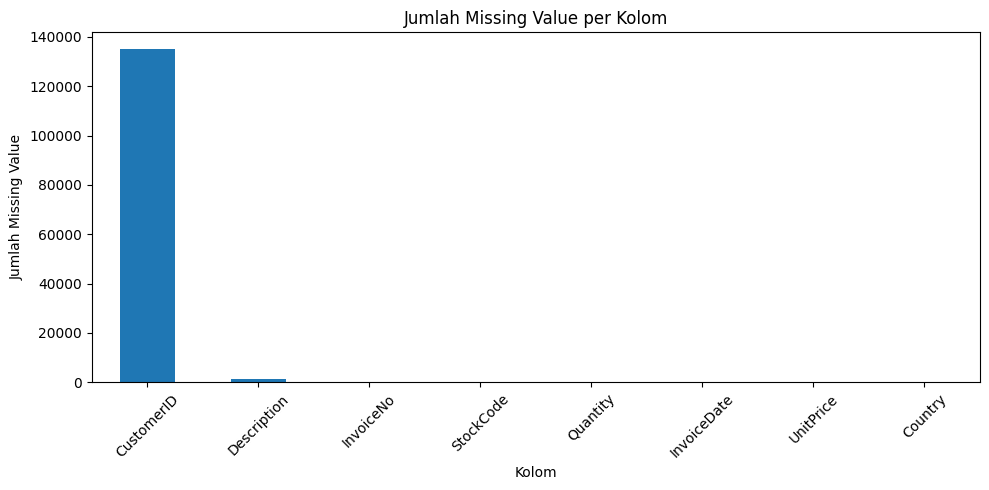

In [3]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Jumlah missing value per kolom:")
print(missing_values)

plt.figure(figsize=(10, 5))
missing_values.plot(kind="bar")
plt.title("Jumlah Missing Value per Kolom")
plt.xlabel("Kolom")
plt.ylabel("Jumlah Missing Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Invoice pembatalan biasanya diawali huruf C
cancelled_invoice = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print("Jumlah baris transaksi pembatalan:")
print(len(cancelled_invoice))

print("\nContoh transaksi pembatalan:")
cancelled_invoice.head()

Jumlah baris transaksi pembatalan:
9288

Contoh transaksi pembatalan:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [5]:
invalid_quantity = df[df["Quantity"] <= 0]
invalid_price = df[df["UnitPrice"] <= 0]

print("Jumlah baris dengan Quantity <= 0:", len(invalid_quantity))
print("Jumlah baris dengan UnitPrice <= 0:", len(invalid_price))

Jumlah baris dengan Quantity <= 0: 10624
Jumlah baris dengan UnitPrice <= 0: 2517


In [6]:
df_clean = df.copy()

# Hapus missing value penting
df_clean = df_clean.dropna(subset=["InvoiceNo", "Quantity", "UnitPrice"])

# Hapus invoice pembatalan
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

# Hapus quantity dan harga yang tidak valid
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("Ukuran dataset sebelum cleaning:", df.shape)
print("Ukuran dataset setelah cleaning:", df_clean.shape)

df_clean.head()

Ukuran dataset sebelum cleaning: (541909, 8)
Ukuran dataset setelah cleaning: (530104, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df_clean["LineTotal"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[["InvoiceNo", "Quantity", "UnitPrice", "LineTotal"]].head()

,InvoiceNo,Quantity,UnitPrice,LineTotal
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


In [8]:
invoice_total = (
    df_clean
    .groupby("InvoiceNo", as_index=False)
    .agg(
        InvoiceTotal=("LineTotal", "sum"),
        TotalItems=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique")
    )
)

invoice_total.head()

,InvoiceNo,InvoiceTotal,TotalItems,UniqueProducts
0,536365,139.12,40,7
1,536366,22.20,12,2
2,536367,278.73,83,12
3,536368,70.05,15,4
4,536369,17.85,3,1


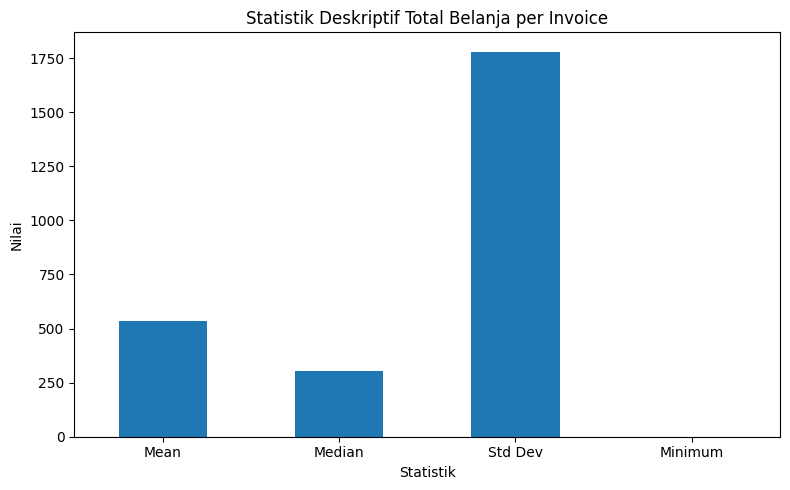

In [9]:
n = len(invoice_total)
mean_invoice = invoice_total["InvoiceTotal"].mean()
median_invoice = invoice_total["InvoiceTotal"].median()
std_invoice = invoice_total["InvoiceTotal"].std()
min_invoice = invoice_total["InvoiceTotal"].min()
max_invoice = invoice_total["InvoiceTotal"].max()

summary_stats = pd.DataFrame({
    "Statistik": [
        "Jumlah Invoice",
        "Rata-rata Invoice",
        "Median Invoice",
        "Standar Deviasi",
        "Minimum",
        "Maksimum"
    ],
    "Nilai": [
        n,
        mean_invoice,
        median_invoice,
        std_invoice,
        min_invoice,
        max_invoice
    ]
})

summary_stats

plot_stats = pd.Series({
    "Mean": mean_invoice,
    "Median": median_invoice,
    "Std Dev": std_invoice,
    "Minimum": min_invoice
})

plt.figure(figsize=(8, 5))
plot_stats.plot(kind="bar")
plt.title("Statistik Deskriptif Total Belanja per Invoice")
plt.xlabel("Statistik")
plt.ylabel("Nilai")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Uji Hipotesis dengan Z-Score

Bagian ini mengikuti konsep pada PPT: tentukan hipotesis, tentukan alpha, hitung nilai z, hitung p-value, lalu ambil keputusan.

Karena pengujian klaim adalah apakah rata-rata tagihan invoice sama dengan £50 atau tidak, maka digunakan **two-tailed z-test**:

- H0: μ = 50
- H1: μ ≠ 50
- α = 0.05
- Critical value two-tailed: z = ±1.96

Rumus z-score:

z = (x̄ - μ0) / (s / √n)


In [10]:
mu0 = 50
alpha = 0.05

print("Rumusan Hipotesis")
print("H0: μ = 50")
print("H1: μ ≠ 50")
print()
print("Jenis uji: Two-tailed test")
print("Significance level (alpha):", alpha)

Rumusan Hipotesis
H0: μ = 50
H1: μ ≠ 50

Jenis uji: Two-tailed test
Significance level (alpha): 0.05


In [11]:
# =========================
# Z-Test Manual (sesuai konsep PPT)
# =========================
# Karena ukuran sampel invoice sangat besar, distribusi sampling mean dapat didekati
# dengan distribusi normal berdasarkan Central Limit Theorem.
# Rumus z-score:
# z = (x_bar - mu0) / (s / sqrt(n))

z_manual = (mean_invoice - mu0) / (std_invoice / np.sqrt(n))
standard_error = std_invoice / np.sqrt(n)

print("Perhitungan Manual One-Sample Z-Test")
print("n:", n)
print("Sample mean (x_bar):", mean_invoice)
print("Hypothesized mean (mu0):", mu0)
print("Sample standard deviation (s):", std_invoice)
print("Standard error:", standard_error)
print("z-score manual:", z_manual)

# Two-tailed p-value: P(Z <= -|z|) + P(Z >= |z|)
p_value_manual = 2 * (1 - stats.norm.cdf(abs(z_manual)))

print("p-value manual:", p_value_manual)


Perhitungan Manual One-Sample Z-Test
n: 19960
Sample mean (x_bar): 534.403033266533
Hypothesized mean (mu0): 50
Sample standard deviation (s): 1780.48764759875
Standard error: 12.602557759707356
z-score manual: 38.43688261562718
p-value manual: 0.0


In [12]:
# =========================
# Validasi Z-Test dengan Distribusi Normal
# =========================
# Tidak memakai t-test lagi. Kita langsung memakai CDF distribusi normal standar.

z_stat = z_manual
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("Hasil One-Sample Z-Test")
print("z-statistic:", z_stat)
print("p-value:", p_value)


Hasil One-Sample Z-Test
z-statistic: 38.43688261562718
p-value: 0.0


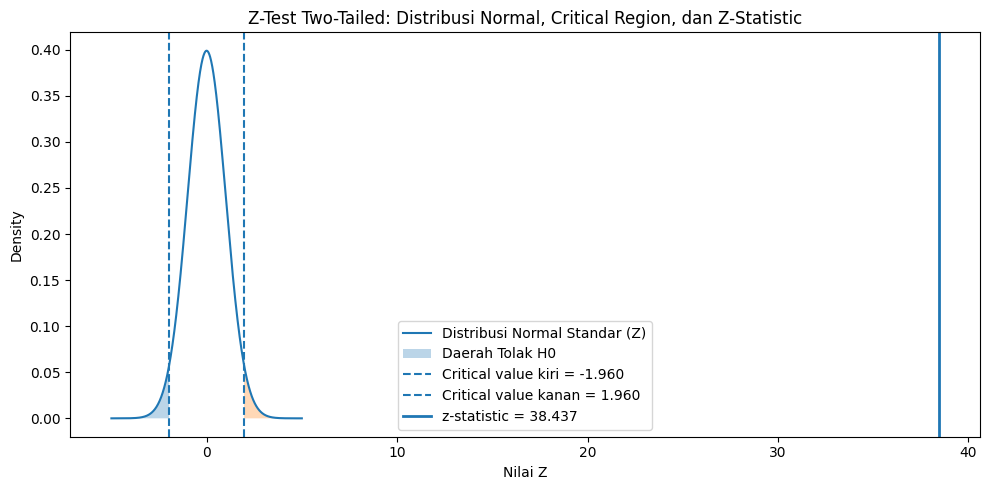

In [13]:
# =========================
# Visualisasi Z-Test: Distribusi Normal, Critical Region, dan Z-Statistic
# =========================

x = np.linspace(-5, 5, 1000)
y = stats.norm.pdf(x)

critical_left = stats.norm.ppf(alpha / 2)
critical_right = stats.norm.ppf(1 - alpha / 2)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Distribusi Normal Standar (Z)")

# Area rejection region kiri
x_left = x[x <= critical_left]
y_left = stats.norm.pdf(x_left)
plt.fill_between(x_left, y_left, alpha=0.3, label="Daerah Tolak H0")

# Area rejection region kanan
x_right = x[x >= critical_right]
y_right = stats.norm.pdf(x_right)
plt.fill_between(x_right, y_right, alpha=0.3)

plt.axvline(critical_left, linestyle="--", label=f"Critical value kiri = {critical_left:.3f}")
plt.axvline(critical_right, linestyle="--", label=f"Critical value kanan = {critical_right:.3f}")
plt.axvline(z_stat, linestyle="-", linewidth=2, label=f"z-statistic = {z_stat:.3f}")

plt.title("Z-Test Two-Tailed: Distribusi Normal, Critical Region, dan Z-Statistic")
plt.xlabel("Nilai Z")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# =========================
# Confidence Interval 95% berbasis Z
# =========================

confidence_level = 0.95
z_critical = stats.norm.ppf(1 - alpha / 2)

ci_lower = mean_invoice - z_critical * standard_error
ci_upper = mean_invoice + z_critical * standard_error

print("Confidence Interval 95% untuk rata-rata invoice menggunakan Z:")
print("Z critical:", z_critical)
print("Lower bound:", ci_lower)
print("Upper bound:", ci_upper)


Confidence Interval 95% untuk rata-rata invoice menggunakan Z:
Z critical: 1.959963984540054
Lower bound: 509.70247394442083
Upper bound: 559.1035925886453


In [15]:
# =========================
# Keputusan Uji Hipotesis
# =========================

print("Aturan keputusan:")
print("Tolak H0 jika p-value <= alpha")
print("Atau, untuk two-tailed test, tolak H0 jika |z| > z critical")
print()

if p_value <= alpha:
    decision = "Tolak H0"
    interpretation = (
        "Terdapat cukup bukti statistik bahwa rata-rata tagihan belanja "
        "per invoice berbeda signifikan dari £50. Dengan demikian, klaim "
        "bahwa rata-rata tagihan per invoice adalah £50 tidak didukung oleh data."
    )
else:
    decision = "Gagal menolak H0"
    interpretation = (
        "Tidak terdapat cukup bukti statistik bahwa rata-rata tagihan belanja "
        "per invoice berbeda signifikan dari £50. Dengan demikian, klaim "
        "bahwa rata-rata tagihan per invoice adalah £50 masih dapat diterima secara statistik."
    )

print("Keputusan:", decision)
print("Interpretasi:", interpretation)


Aturan keputusan:
Tolak H0 jika p-value <= alpha
Atau, untuk two-tailed test, tolak H0 jika |z| > z critical

Keputusan: Tolak H0
Interpretasi: Terdapat cukup bukti statistik bahwa rata-rata tagihan belanja per invoice berbeda signifikan dari £50. Dengan demikian, klaim bahwa rata-rata tagihan per invoice adalah £50 tidak didukung oleh data.
